## Exercise 1.2 — Mass of a 2D Disk

**Problem:** Find the mass of a two-dimensional disk:
- Centered at the **origin**
- Radius: **R = 5 cm**
- Density function: $\rho(r) = \sqrt{3r}$ gr/cm²

**Setup — integrating over thin rings:**

For a 2D object with radial symmetry, divide the disk into thin rings of radius $r$ and width $dr$. Each ring has area $dA = 2\pi r\, dr$, so:

$$M = \int_0^R \rho(r)\, 2\pi r\, dr = \int_0^5 \sqrt{3r} \cdot 2\pi r\, dr = 2\pi\sqrt{3} \int_0^5 r^{3/2}\, dr$$

**Analytical Solution:**

$$M = 2\pi\sqrt{3} \cdot \left[\frac{2}{5} r^{5/2}\right]_0^5 = 2\pi\sqrt{3} \cdot \frac{2}{5} \cdot 5^{5/2} = 2\pi\sqrt{3} \cdot 10\sqrt{5} = 20\pi\sqrt{15}$$

**Answer: $M = 20\pi\sqrt{15}$ g**

**Methods used:** Trapezoidal Rule & Simpson's Rule

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Define the Integrand and Parameters

In [2]:
# Density function
def rho(r):
    """rho(r) = sqrt(3r)  [g/cm^2]"""
    return np.sqrt(3 * r)

# Integrand: rho(r) * 2*pi*r  (ring area element)
def integrand(r):
    return rho(r) * 2 * np.pi * r

# Parameters
R = 5            # radius in cm
a, b = 0, R      # integration limits
n = 1000         # sub-intervals (must be even for Simpson's)
h = (b - a) / n  # step size
r = np.linspace(a, b, n + 1)
f = integrand(r)

print(f'Radius    : R = {R} cm')
print(f'Interval  : [{a}, {b}] cm')
print(f'Intervals : n = {n}')
print(f'Step size : h = {h:.4f} cm')

Radius    : R = 5 cm
Interval  : [0, 5] cm
Intervals : n = 1000
Step size : h = 0.0050 cm


## 2. Plot the Density and Integrand

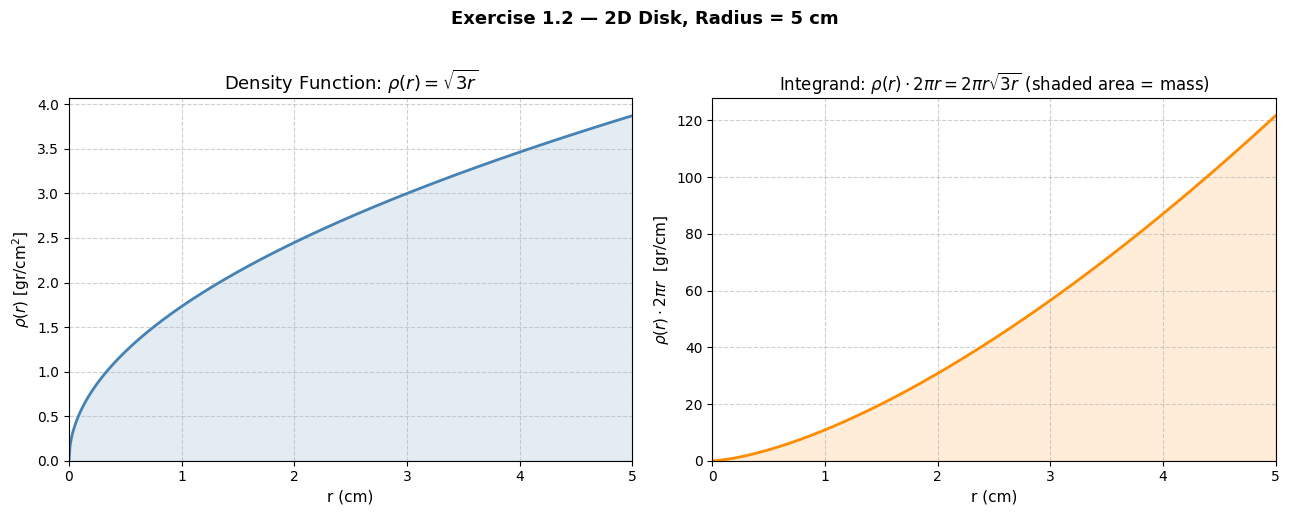

In [3]:
r_plot = np.linspace(0, R, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: density function rho(r)
ax1 = axes[0]
ax1.plot(r_plot, rho(r_plot), color='steelblue', linewidth=2)
ax1.fill_between(r_plot, rho(r_plot), alpha=0.15, color='steelblue')
ax1.set_title(r'Density Function: $\rho(r) = \sqrt{3r}$', fontsize=13)
ax1.set_xlabel('r (cm)', fontsize=11)
ax1.set_ylabel(r'$\rho(r)$ [gr/cm$^2$]', fontsize=11)
ax1.set_xlim(0, R)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.6)

# Right: integrand rho(r)*2*pi*r
ax2 = axes[1]
ax2.plot(r_plot, integrand(r_plot), color='darkorange', linewidth=2)
ax2.fill_between(r_plot, integrand(r_plot), alpha=0.15, color='darkorange')
ax2.set_title(r'Integrand: $\rho(r) \cdot 2\pi r = 2\pi r\sqrt{3r}$ (shaded area = mass)', fontsize=12)
ax2.set_xlabel('r (cm)', fontsize=11)
ax2.set_ylabel(r'$\rho(r)\cdot 2\pi r$  [gr/cm]', fontsize=11)
ax2.set_xlim(0, R)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Exercise 1.2 — 2D Disk, Radius = 5 cm', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Trapezoidal Rule

$$M \approx \frac{h}{2}\left[g(r_0) + 2g(r_1) + \cdots + 2g(r_{n-1}) + g(r_n)\right], \quad g(r) = 2\pi r\sqrt{3r}$$

In [4]:
mass_trap = h * (0.5 * f[0] + np.sum(f[1:-1]) + 0.5 * f[-1])
print(f'Mass (Trapezoidal Rule) = {mass_trap:,.6f} g')

Mass (Trapezoidal Rule) = 243.346796 g


## 4. Simpson's Rule

$$M \approx \frac{h}{3}\left[g(r_0) + 4g(r_1) + 2g(r_2) + 4g(r_3) + \cdots + g(r_n)\right]$$

In [5]:
coeffs = np.ones(n + 1)
coeffs[1:-1:2] = 4   # odd indices  -> coefficient 4
coeffs[2:-2:2] = 2   # even indices -> coefficient 2
mass_simp = (h / 3) * np.dot(coeffs, f)
print(f"Mass (Simpson's Rule) = {mass_simp:,.6f} g")

Mass (Simpson's Rule) = 243.346721 g


## 5. Analytical (Exact) Solution

$$M = 2\pi\sqrt{3} \int_0^5 r^{3/2}\, dr = 2\pi\sqrt{3} \cdot \frac{2}{5} \cdot 5^{5/2} = 20\pi\sqrt{15}$$

In [6]:
mass_exact = 20 * math.pi * math.sqrt(15)
print(f'Mass (Exact) = 20*pi*sqrt(15) = {mass_exact:,.6f} g')

Mass (Exact) = 20*pi*sqrt(15) = 243.346721 g


## 6. Error Estimation

In [7]:
err_trap = abs(mass_exact - mass_trap)
err_simp = abs(mass_exact - mass_simp)
rel_trap = err_trap / mass_exact * 100
rel_simp = err_simp / mass_exact * 100

print('=' * 60)
print('   Results Summary')
print('=' * 60)
print(f'  Exact (20*pi*sqrt(15)) : {mass_exact:>16,.6f} g')
print(f'  Trapezoidal Rule       : {mass_trap:>16,.6f} g')
print(f"  Simpson's Rule         : {mass_simp:>16,.6f} g")
print('-' * 60)
print(f'  Error (Trap) abs : {err_trap:.4e} g   rel : {rel_trap:.4e} %')
print(f"  Error (Simp) abs : {err_simp:.4e} g   rel : {rel_simp:.4e} %")
print('=' * 60)

   Results Summary
  Exact (20*pi*sqrt(15)) :       243.346721 g
  Trapezoidal Rule       :       243.346796 g
  Simpson's Rule         :       243.346721 g
------------------------------------------------------------
  Error (Trap) abs : 7.5556e-05 g   rel : 3.1049e-05 %
  Error (Simp) abs : 2.7078e-07 g   rel : 1.1127e-07 %


## 7. Error Comparison Plot

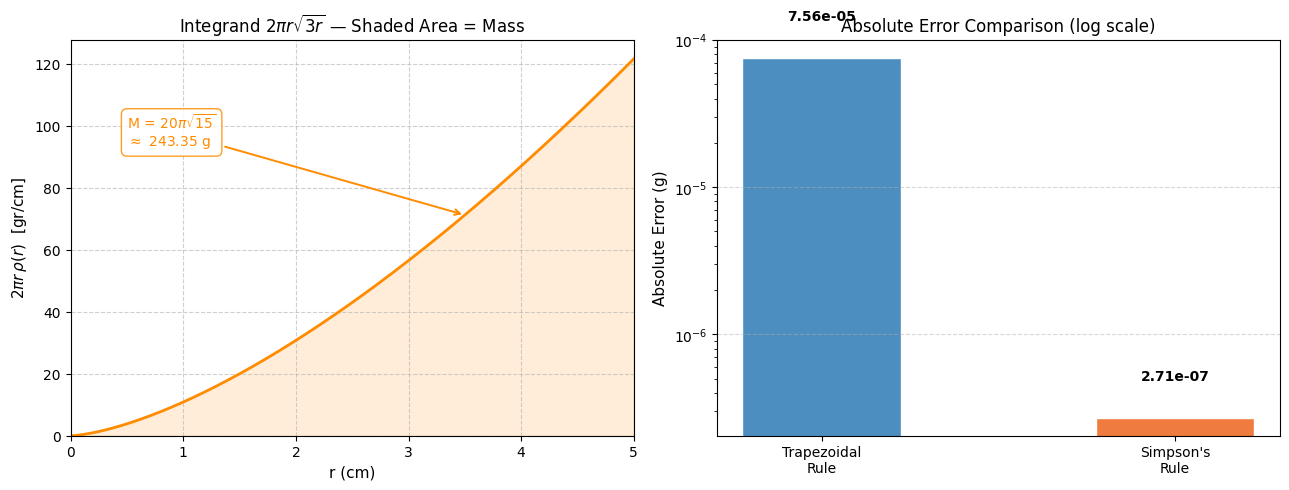


Simpson's Rule is ~279x more accurate than the Trapezoidal Rule.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: integrand with shaded area
ax1 = axes[0]
ax1.fill_between(r_plot, integrand(r_plot), alpha=0.15, color='darkorange')
ax1.plot(r_plot, integrand(r_plot), color='darkorange', linewidth=2)
ax1.set_title(r'Integrand $2\pi r\sqrt{3r}$ — Shaded Area = Mass', fontsize=12)
ax1.set_xlabel('r (cm)', fontsize=11)
ax1.set_ylabel(r'$2\pi r\,\rho(r)$  [gr/cm]', fontsize=11)
ax1.set_xlim(0, R)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.annotate(
    f'M = $20\\pi\\sqrt{{15}}$\n$\\approx$ {mass_exact:,.2f} g',
    xy=(3.5, integrand(3.5)), xytext=(0.5, integrand(4.2)), fontsize=10, color='darkorange',
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.4),
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='darkorange', alpha=0.85)
)

# Right: error bar chart
ax2 = axes[1]
methods = ['Trapezoidal\nRule', "Simpson's\nRule"]
errors  = [err_trap, err_simp]
colors  = ['#4C8EBF', '#F07B3F']
bars = ax2.bar(methods, errors, color=colors, width=0.45, edgecolor='white')
ax2.set_title('Absolute Error Comparison (log scale)', fontsize=12)
ax2.set_ylabel('Absolute Error (g)', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar, err in zip(bars, errors):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.8,
             f'{err:.2e}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSimpson's Rule is ~{err_trap/err_simp:,.0f}x more accurate than the Trapezoidal Rule.")